In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. توليد بيانات إنتاج تاريخية لبئر على مدار 12 شهراً
months = pd.date_range(start="2025-01-01", periods=12, freq="ME")

# محاكاة هبوط إنتاج النفط
oil_production = [5000, 4800, 4650, 4400, 4100, 3900, 3600, 3300, 3100, 2800, 2500, 2200]
# محاكاة هبوط ضغط القاع البئري
bhp = [3500, 3420, 3350, 3210, 3100, 2950, 2800, 2680, 2550, 2400, 2250, 2100]
# محاكاة صعود وثوران الماء في البئر
water_cut = [1.0, 2.5, 4.0, 8.5, 12.0, 18.5, 25.0, 35.0, 48.0, 60.0, 72.0, 85.0]

# 2. تجميع البيانات في Pandas DataFrame
production_df = pd.DataFrame({
    'Month': months,
    'Oil_Prod': oil_production,
    'BHP': bhp,
    'Water_Cut': water_cut
})

print("✅ تم توليد وتجهيز السجل التاريخي لإنتاج البئر بنجاح!")

✅ تم توليد وتجهيز السجل التاريخي لإنتاج البئر بنجاح!


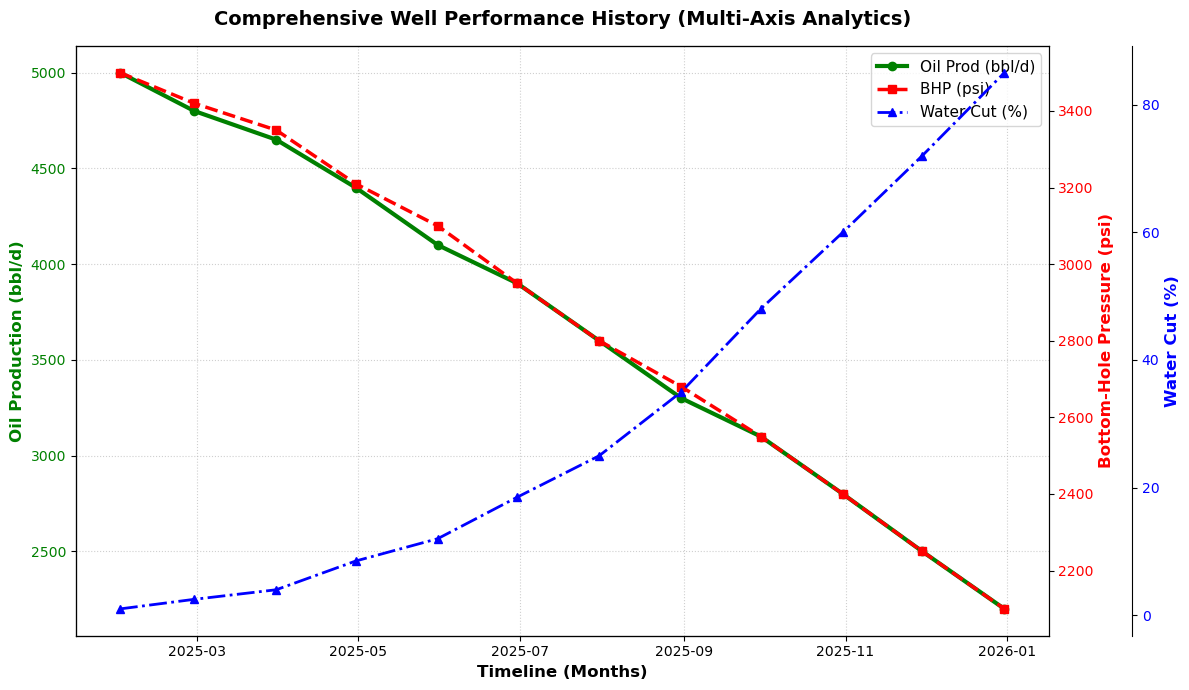

In [2]:
# 1. إنشاء الشكل والمحور الرئيسي الأول (النفط - جهة اليسار)
fig, ax1 = plt.subplots(figsize=(12, 7))

# رسم خط إنتاج النفط
line1 = ax1.plot(production_df['Month'], production_df['Oil_Prod'], 
                 color='green', linewidth=3, marker='o', label='Oil Prod (bbl/d)')
ax1.set_xlabel('Timeline (Months)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Oil Production (bbl/d)', color='green', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. إنشاء المحور الثاني التوأم (الضغط - جهة اليمين)
ax2 = ax1.twinx()
line2 = ax2.plot(production_df['Month'], production_df['BHP'], 
                 color='red', linewidth=2.5, linestyle='--', marker='s', label='BHP (psi)')
ax2.set_ylabel('Bottom-Hole Pressure (psi)', color='red', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

# 3. إنشاء المحور الثالث (نسبة الماء - ممتد جهة اليمين أبعد)
ax3 = ax1.twinx()
# إزاحة المحور الثالث لكي لا يتداخل مع المحور الثاني
ax3.spines['right'].set_position(('outward', 60))
line3 = ax3.plot(production_df['Month'], production_df['Water_Cut'], 
                 color='blue', linewidth=2, linestyle='-.', marker='^', label='Water Cut (%)')
ax3.set_ylabel('Water Cut (%)', color='blue', fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='blue')

# 4. دمج التسميات (Legends) من كافة المحاور في صندوق واحد
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=11)

# 5. العنوان واللمسات النهائية
plt.title('Comprehensive Well Performance History (Multi-Axis Analytics)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()

# عرض الرسمة
plt.show()